# Notebook 4 — Learning slope by sex and circadian classification

Old animals only. Circadian classification is the **directional composite split**
from Notebook 2 (`dysfunction_score`, median split): higher composite z-score
=> **vulnerable**; otherwise **resilient**.

This notebook:
1. Loads the per-animal classification CSV and merges Barnes learning slopes.
2. Plots learning slope by Sex x circadian_group (bar + SEM + dot overlay).
3. Plots the **percentage of old males vs old females** classified as vulnerable.
4. Runs a 2-way ANOVA (Sex x circadian_group) on learning slope.
5. Addresses whether z-scoring would help with the unbalanced cell sizes.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

sns.set_context("notebook")
sns.set_style("whitegrid")

HERE = Path.cwd()                      # poster_analysis/vulnerability_resilience_analysis/
REPO = HERE.parent.parent

df = pd.read_csv(HERE / "dysfunction_classifications.csv")
slopes = pd.read_csv(REPO / "learning_slopes_per_mouse.csv")[["ID", "learning_slope"]]
df = df.merge(slopes, on="ID", how="left")

print(f"Old animals total: n = {len(df)}")
print(f"With learning slope + circadian group: n = "
      f"{df.dropna(subset=['learning_slope','circadian_group']).shape[0]}")

ORDER_X    = ["Female", "Male"]
ORDER_HUE  = ["resilient", "vulnerable"]
PALETTE    = {"resilient": "#5fc4be", "vulnerable": "#e07a9c"}


Old animals total: n = 40
With learning slope + circadian group: n = 38


## 1. Bar chart — learning slope by Sex x circadian_group

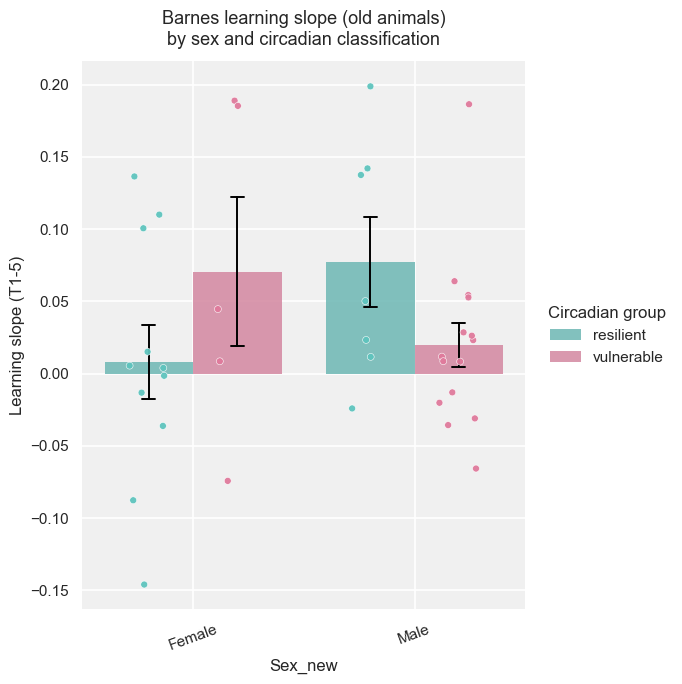


Mean +/- SEM:
                          mean    sem  count
Sex_new circadian_group                     
Female  resilient        0.008  0.025     11
        vulnerable       0.071  0.051      5
Male    resilient        0.077  0.031      7
        vulnerable       0.020  0.015     15


In [2]:
plot_df = df.dropna(subset=["learning_slope", "circadian_group", "Sex_new"]).copy()

fig, ax = plt.subplots(figsize=(7, 7))

sns.barplot(
    data=plot_df, x="Sex_new", y="learning_slope", hue="circadian_group",
    order=ORDER_X, hue_order=ORDER_HUE, palette=PALETTE,
    errorbar="se", capsize=0.12, err_kws={"linewidth": 1.4, "color": "black"},
    edgecolor="none", alpha=0.85, ax=ax,
)
sns.stripplot(
    data=plot_df, x="Sex_new", y="learning_slope", hue="circadian_group",
    order=ORDER_X, hue_order=ORDER_HUE, palette=PALETTE,
    dodge=True, jitter=0.18, size=5, alpha=0.95,
    edgecolor="white", linewidth=0.4, ax=ax, legend=False,
)

ax.set_title("Barnes learning slope (old animals)\nby sex and circadian classification",
             fontsize=13, pad=12)
ax.set_xlabel("Sex_new"); ax.set_ylabel("Learning slope (T1-5)")
ax.tick_params(axis="x", labelrotation=20)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Circadian group",
          loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.set_facecolor("#f0f0f0")
for s in ax.spines.values(): s.set_visible(False)
ax.grid(True, color="white", linewidth=1.2)
plt.tight_layout(); plt.show()

print("\nMean +/- SEM:")
print(plot_df.groupby(["Sex_new", "circadian_group"])["learning_slope"]
      .agg(["mean", "sem", "count"]).round(3).to_string())


## 2. Percentage of vulnerable animals — old males vs old females

Same circadian classification, just summarised as a sex-level proportion.
This makes the cell-size imbalance visible (which then matters for the ANOVA).


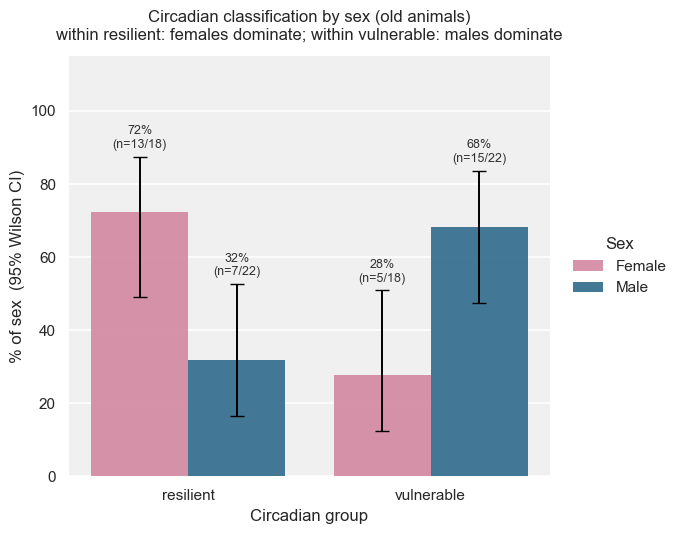

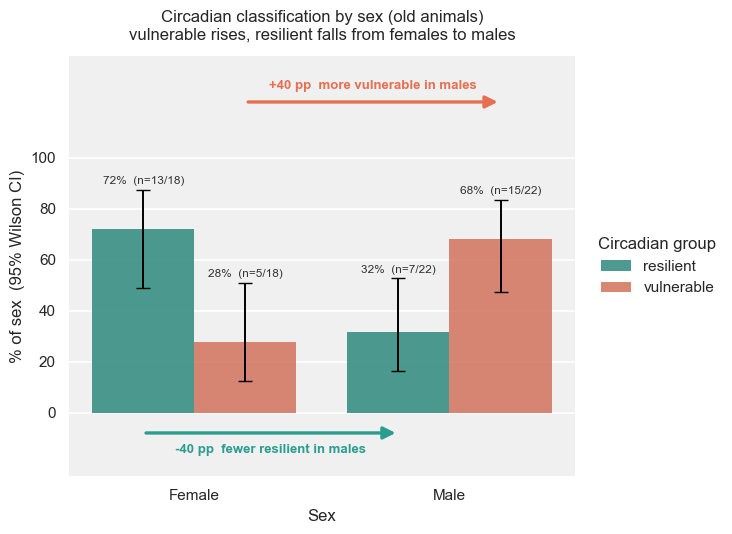

Contingency table:
circadian_group  resilient  vulnerable
Sex_new                               
Female                  13           5
Male                     7          15

Chi-squared(Sex x circadian_group) = 4.95, dof=1, p=0.0261
Fisher's exact: odds ratio = 5.57, p = 0.0248


In [3]:
from statsmodels.stats.proportion import proportion_confint

pct_df = df.dropna(subset=["circadian_group"]).copy()
rows = []
for sex in ORDER_X:
    sub = pct_df[pct_df["Sex_new"] == sex]
    n_total = len(sub)
    for grp in ORDER_HUE:
        k = (sub["circadian_group"] == grp).sum()
        p_hat = k / n_total * 100 if n_total else np.nan
        lo, hi = proportion_confint(k, n_total, alpha=0.05, method="wilson")
        rows.append({"Sex_new": sex, "circadian_group": grp,
                     "pct": p_hat, "n": k, "n_total": n_total,
                     "lo": lo*100, "hi": hi*100})
pct = pd.DataFrame(rows)

SEX_PALETTE = {"Female": "#e07a9c", "Male": "#1f6f9b"}
GROUP_ORDER = ["resilient", "vulnerable"]
SEX_ORDER   = ["Female", "Male"]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.barplot(
    data=pct, x="circadian_group", y="pct", hue="Sex_new",
    order=GROUP_ORDER, hue_order=SEX_ORDER, palette=SEX_PALETTE,
    edgecolor="none", alpha=0.9, ax=ax,
)

# Wilson 95% CI error bars + label per bar
for bar, (sex, grp) in zip(
        ax.patches,
        [(s, g) for s in SEX_ORDER for g in GROUP_ORDER]):
    row = pct[(pct["Sex_new"] == sex) & (pct["circadian_group"] == grp)].iloc[0]
    x = bar.get_x() + bar.get_width()/2
    ax.errorbar(x, row["pct"],
                yerr=[[row["pct"] - row["lo"]], [row["hi"] - row["pct"]]],
                fmt="none", ecolor="black", elinewidth=1.4, capsize=5)
    ax.text(x, row["hi"] + 1.5,
            f"{row['pct']:.0f}%\n(n={int(row['n'])}/{int(row['n_total'])})",
            ha="center", va="bottom", fontsize=9, color="#333")

ax.set_title("Circadian classification by sex (old animals)\n"
             "within resilient: females dominate; within vulnerable: males dominate",
             fontsize=12, pad=12)
ax.set_xlabel("Circadian group"); ax.set_ylabel("% of sex  (95% Wilson CI)")
ax.set_ylim(0, 115)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.legend(title="Sex", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.set_facecolor("#f0f0f0")
for s in ax.spines.values(): s.set_visible(False)
ax.grid(True, color="white", linewidth=1.2, axis="y")
plt.tight_layout(); plt.show()

# ---------- Alternate view: x = Sex, hue = circadian_group, with trend arrows ----------
# Different palette so it does not clash with the Female/Male blue+pink above.
ALT_PALETTE = {"resilient": "#2a9d8f", "vulnerable": "#e76f51"}  # teal, coral
ALT_X       = ["Female", "Male"]
ALT_HUE     = ["resilient", "vulnerable"]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.barplot(
    data=pct, x="Sex_new", y="pct", hue="circadian_group",
    order=ALT_X, hue_order=ALT_HUE, palette=ALT_PALETTE,
    edgecolor="none", alpha=0.9, ax=ax,
)
for bar, (grp, sex) in zip(
        ax.patches,
        [(g, s) for g in ALT_HUE for s in ALT_X]):
    row = pct[(pct["Sex_new"] == sex) & (pct["circadian_group"] == grp)].iloc[0]
    x = bar.get_x() + bar.get_width()/2
    ax.errorbar(x, row["pct"],
                yerr=[[row["pct"] - row["lo"]], [row["hi"] - row["pct"]]],
                fmt="none", ecolor="black", elinewidth=1.4, capsize=5)
    ax.text(x, row["hi"] + 1.5,
            f"{row['pct']:.0f}%  (n={int(row['n'])}/{int(row['n_total'])})",
            ha="center", va="bottom", fontsize=8.5, color="#333")

def _bar_xcenter(sex, grp):
    j = ALT_X.index(sex); k = ALT_HUE.index(grp)
    return j + (-0.2 if k == 0 else 0.2)

vul_F = pct[(pct["Sex_new"]=="Female") & (pct["circadian_group"]=="vulnerable")].iloc[0]
vul_M = pct[(pct["Sex_new"]=="Male")   & (pct["circadian_group"]=="vulnerable")].iloc[0]
res_F = pct[(pct["Sex_new"]=="Female") & (pct["circadian_group"]=="resilient")].iloc[0]
res_M = pct[(pct["Sex_new"]=="Male")   & (pct["circadian_group"]=="resilient")].iloc[0]

# Trend arrows in dedicated whitespace bands above and below the bars.
TOP_Y = 122
BOT_Y = -8

ax.annotate("", xy=(_bar_xcenter("Male", "vulnerable"), TOP_Y),
            xytext=(_bar_xcenter("Female", "vulnerable"), TOP_Y),
            arrowprops=dict(arrowstyle="-|>", color=ALT_PALETTE["vulnerable"],
                            lw=2.4, mutation_scale=18))
ax.text((_bar_xcenter("Female", "vulnerable") + _bar_xcenter("Male", "vulnerable"))/2,
        TOP_Y + 4,
        f"+{vul_M['pct'] - vul_F['pct']:.0f} pp  more vulnerable in males",
        ha="center", va="bottom", fontsize=9.5,
        color=ALT_PALETTE["vulnerable"], fontweight="bold")

ax.annotate("", xy=(_bar_xcenter("Male", "resilient"), BOT_Y),
            xytext=(_bar_xcenter("Female", "resilient"), BOT_Y),
            arrowprops=dict(arrowstyle="-|>", color=ALT_PALETTE["resilient"],
                            lw=2.4, mutation_scale=18))
ax.text((_bar_xcenter("Female", "resilient") + _bar_xcenter("Male", "resilient"))/2,
        BOT_Y - 4,
        f"{res_M['pct'] - res_F['pct']:.0f} pp  fewer resilient in males",
        ha="center", va="top", fontsize=9.5,
        color=ALT_PALETTE["resilient"], fontweight="bold")

ax.set_title("Circadian classification by sex (old animals)\n"
             "vulnerable rises, resilient falls from females to males",
             fontsize=12, pad=12)
ax.set_xlabel("Sex"); ax.set_ylabel("% of sex  (95% Wilson CI)")
ax.set_ylim(-25, 140)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.legend(title="Circadian group", loc="center left", bbox_to_anchor=(1.02, 0.5),
          frameon=False)
ax.set_facecolor("#f0f0f0")
for s in ax.spines.values(): s.set_visible(False)
ax.grid(True, color="white", linewidth=1.2, axis="y")
plt.tight_layout(); plt.show()

# Chi-squared test on the 2x2 (Sex x circadian_group)
tab = pd.crosstab(df["Sex_new"], df["circadian_group"])
print("Contingency table:\n", tab, sep="")
chi2, p, dof, _ = stats.chi2_contingency(tab)
print(f"\nChi-squared(Sex x circadian_group) = {chi2:.2f}, dof={dof}, p={p:.4f}")
odds, p_fish = stats.fisher_exact(tab.values)
print(f"Fisher's exact: odds ratio = {odds:.2f}, p = {p_fish:.4f}")


## 3. Two-way ANOVA — Sex x circadian_group on learning slope

Type III SS so the unbalanced cells (F: 11 res / 5 vul; M: 7 res / 15 vul) are
handled correctly. We also report Levene's test (variance equality) and the
descriptive cell means; an interaction term is included because the bar chart
suggests the effect of vulnerability flips sign between sexes.


In [4]:
mod = smf.ols("learning_slope ~ C(Sex_new) * C(circadian_group)",
              data=plot_df).fit()
anova = sm.stats.anova_lm(mod, typ=3)
print("Type III ANOVA:\n", anova.round(4), sep="")

# Levene's test (variance homogeneity across the four cells)
groups = [g["learning_slope"].values
          for _, g in plot_df.groupby(["Sex_new", "circadian_group"])]
W, p_lev = stats.levene(*groups, center="median")
print(f"\nLevene's test (median-centered): W = {W:.3f}, p = {p_lev:.4f}")

print("\nCell means (sanity check):")
print(plot_df.groupby(['Sex_new','circadian_group'])['learning_slope']
      .agg(['mean','sem','count']).round(3).to_string())


Type III ANOVA:
                               sum_sq    df       F  PR(>F)
Intercept                      0.0007   1.0  0.1117  0.7403
C(Sex_new)                     0.0204   1.0  3.2708  0.0794
C(circadian_group)             0.0135   1.0  2.1635  0.1505
C(Sex_new):C(circadian_group)  0.0287   1.0  4.5930  0.0393
Residual                       0.2123  34.0     NaN     NaN

Levene's test (median-centered): W = 1.301, p = 0.2901

Cell means (sanity check):
                          mean    sem  count
Sex_new circadian_group                     
Female  resilient        0.008  0.025     11
        vulnerable       0.071  0.051      5
Male    resilient        0.077  0.031      7
        vulnerable       0.020  0.015     15


### Interaction plot — visualising Sex x circadian_group  (F = 4.59, p = 0.039)

Cell means with SEM error bars and individual mice overlaid as dots; lines connect
the two circadian groups within each sex so the *crossover* (the interaction) is
visible at a glance.


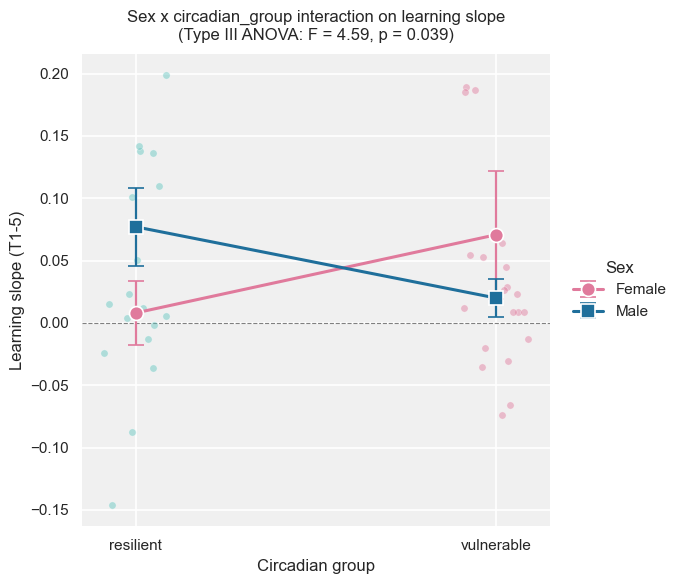

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

# Individual points (jittered) underneath
for j, sex in enumerate(ORDER_X):
    for k, grp in enumerate(ORDER_HUE):
        sub = plot_df[(plot_df["Sex_new"] == sex) & (plot_df["circadian_group"] == grp)]
        rng = np.random.default_rng(42 + j*10 + k)
        x_center = k
        xs = x_center + (rng.random(len(sub)) - 0.5) * 0.18
        ax.scatter(xs, sub["learning_slope"].values, s=28,
                   color=PALETTE[grp], alpha=0.45, edgecolor="white",
                   linewidth=0.5, zorder=2)

# Cell means + SEM, joined by a line per sex
SEX_COLOR = {"Female": "#e07a9c", "Male": "#1f6f9b"}
SEX_MARKER = {"Female": "o", "Male": "s"}
for sex in ORDER_X:
    means, sems, xs = [], [], []
    for k, grp in enumerate(ORDER_HUE):
        sub = plot_df[(plot_df["Sex_new"] == sex) & (plot_df["circadian_group"] == grp)]
        means.append(sub["learning_slope"].mean())
        sems.append(sub["learning_slope"].sem())
        xs.append(k)
    ax.errorbar(xs, means, yerr=sems, fmt=SEX_MARKER[sex] + "-",
                color=SEX_COLOR[sex], ecolor=SEX_COLOR[sex],
                elinewidth=1.6, capsize=6, markersize=10, linewidth=2.2,
                label=sex, zorder=4, markeredgecolor="white", markeredgewidth=1.2)

ax.set_xticks([0, 1]); ax.set_xticklabels(ORDER_HUE)
ax.set_xlabel("Circadian group"); ax.set_ylabel("Learning slope (T1-5)")
ax.set_title("Sex x circadian_group interaction on learning slope\n"
             "(Type III ANOVA: F = 4.59, p = 0.039)", fontsize=12, pad=10)
ax.legend(title="Sex", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
ax.set_facecolor("#f0f0f0")
for s in ax.spines.values(): s.set_visible(False)
ax.grid(True, color="white", linewidth=1.2)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--", zorder=1)
plt.tight_layout(); plt.show()


## 4. Should we z-score to account for the unbalanced cell sizes?

**Short answer: no.** Z-scoring is a rescaling, not a fix for unbalanced n.

| What z-scoring does | What unbalanced n needs |
|---|---|
| Centres and rescales a variable so it has mean 0, SD 1 | Different sums-of-squares decomposition (Type II / III) so the test does not depend on the order of factors |
| Removes location/scale information | Preserves location/scale but accounts for cell-size imbalance |

A few specific cases:

- **Z-score `learning_slope` overall.** Just rescales y. The F-statistic and p-values from the ANOVA are *identical* — you have not addressed anything.
- **Z-score `learning_slope` within sex.** Forces every sex to have mean 0, SD 1.
  This *destroys* the main effect of Sex by construction and shrinks/inflates the
  Sex x group interaction depending on within-sex variance. This is the wrong
  move when Sex is one of the factors you are testing.
- **Z-score `learning_slope` within circadian_group.** Same problem mirrored —
  destroys the main effect of group.

**What actually handles unbalanced n:** the Type III ANOVA above, which uses
the partial sums of squares so each effect is tested adjusting for all the
others. With n=5 in the smallest cell, the more conservative move is also to
report:

- Levene's test (above) — if variances differ, use a Welch / heteroscedastic
  variant.
- A non-parametric robustness check (Kruskal-Wallis on the four cells, or a
  permutation test on the interaction term).

If you wanted a transformation, the right one for slope-style outcomes with
heavy tails would be a **rank** or **log** transform — not a z-score. But the
Type III ANOVA already gives you a defensible primary test; z-scoring is not
the lever you want here.


In [6]:
# Robustness checks: rank-based ANOVA + Kruskal-Wallis across the four cells
ranked = plot_df.copy()
ranked["rank_slope"] = ranked["learning_slope"].rank()
mod_r = smf.ols("rank_slope ~ C(Sex_new) * C(circadian_group)", data=ranked).fit()
anova_r = sm.stats.anova_lm(mod_r, typ=3)
print("Type III ANOVA on ranks (robustness check):")
print(anova_r.round(4))

cells = [g["learning_slope"].values
         for _, g in plot_df.groupby(["Sex_new", "circadian_group"])]
H, p = stats.kruskal(*cells)
print(f"\nKruskal-Wallis across the 4 cells: H = {H:.3f}, p = {p:.4f}")


Type III ANOVA on ranks (robustness check):
                                  sum_sq    df        F  PR(>F)
Intercept                      2627.2727   1.0  22.0842  0.0000
C(Sex_new)                      437.8362   1.0   3.6803  0.0635
C(circadian_group)              206.2227   1.0   1.7335  0.1968
C(Sex_new):C(circadian_group)   444.6418   1.0   3.7376  0.0616
Residual                       4044.8416  34.0      NaN     NaN

Kruskal-Wallis across the 4 cells: H = 4.248, p = 0.2359
